# NP.ENS KBDD - breast application

In [1]:
import os, math, time, random, warnings
os.environ['PYTHONWARNINGS'] = 'ignore'   # also silences warnings inside joblib worker processes
warnings.filterwarnings('ignore')         # main process: powerlaw/scipy/pandas/networkx notices
import numpy as np
import pandas as pd
import networkx as nx
import scipy.stats as stats
from itertools import combinations
import powerlaw
import pingouin as pg
import matplotlib.pyplot as plt
from statistics import stdev
from joblib import Parallel, delayed


In [2]:
# ---- configuration ----
BASE = "data/application"   # 52 KEGG reference networks + JAKSTATdata.csv, shipped with this folder
SEED = 20211208            # base seed; structure k is labelled with seed SEED + k
POTENTIAL_NET_SIZE = 32    # number of JAK-STAT genes
M = 100                    # number of degree sequences
TOP_PERCENT = 0.01         # top 1% of structures by Deviation
PERMUTE_TIMES = 100000     # hard cap on labelling iterations per structure
PERMUTE_SIZE = 2           # initial swap size
UPDATE_COUNT = 2000        # escalate swap size after this many consecutive non-improvements
PATIENCE_T = 6000          # C' stop: terminate after this many consecutive non-improvements
N_JOBS = 8                 # parallel workers

## Core functions (Erdos-Gallai enumeration)

In [3]:
def EGtest(DS_input):
    if np.sum(DS_input) % 2 == 1: 
        return 'failure'
    if np.sum(DS_input) != 0 & 0 in DS_input: # ensure 'delete' function could work
        DS_input = np.delete(DS_input, np.where(DS_input == 0)) # remove '0' in DS
    if np.sum(DS_input) > len(DS_input)*(len(DS_input) - 1):  # exclude multiple edge scenario
        return 'failure'
    DS_input = np.sort(DS_input)[::-1]
    for index in range(len(DS_input)): # check EG theorem
        k = index + 1
        tmp_DS_input = np.array([k if DS_input[x] > k and x >= k else DS_input[x] for x in range(len(DS_input))]) # replace element if it's larger than k
        if sum(tmp_DS_input[0:k]) > k*(k-1) + np.sum(tmp_DS_input[k:len(DS_input)]):
            return 'failure'
    return 'success' 


def rightmost_adj(DS_input):
    non_zero_degree_node_index = np.array([i for i, x in enumerate(DS_input) if x > 0])
    if 0 in DS_input:
        DS_input = np.delete(DS_input, np.where(DS_input == 0))
    order_index = np.argsort(-DS_input) # save index for adjacency matrix
    DS_input = np.sort(DS_input)[::-1]
    rightmost_adj_set = np.array([], dtype = int)
    for non_leading_node in range(1,len(DS_input))[::-1]: # run from last-second node to second node 
        tmp_DS = np.copy(DS_input)
        # connect 'non_leading_node' with leading node
        tmp_DS[0] -= 1
        tmp_DS[non_leading_node] -= 1
        # run EG test for checking connection is ok
        if tmp_DS[0] != 0:
            # connect leading node with first i nodes
            DS_for_test = np.array([tmp_DS[i] - 1 if i <= tmp_DS[0] else tmp_DS[i] for i in range(1, len(tmp_DS))])
        else:
            DS_for_test = np.copy(tmp_DS)
        if EGtest(DS_for_test) == 'success':
            rightmost_adj_set = np.append(rightmost_adj_set, non_leading_node)
            if tmp_DS[0] == 0:
                break  #stop when degree of leading node is 0
            DS_input = np.copy(tmp_DS)
    rightmost_adj_set = np.array(non_zero_degree_node_index[order_index[rightmost_adj_set]])   #re-order
    return rightmost_adj_set


def left_adj(current_adj_mat, DS_input_original, DS_input_current, rightmost_adj, leading_node_index):
    leading_node_degree = DS_input_current[leading_node_index]
    tmp_DS = np.copy(DS_input_current)
    tmp_DS[leading_node_index] = 0
    order_index = np.argsort(-tmp_DS)
    tmp_DS = np.sort(tmp_DS)[::-1]
    # remove node withh zero degree
    non_zero_DS = np.delete(tmp_DS, np.where(tmp_DS == 0))
    number_of_min = len(np.where(non_zero_DS == min(non_zero_DS))[0])
    non_min_node_index = np.where(non_zero_DS != min(non_zero_DS))[0]
    number_of_non_min = len(non_min_node_index)
    # parameters for for-loop
    tmp_left_adj_set = [[0]*leading_node_degree] 
    i_start = max(leading_node_degree - number_of_min, 0) # 0要檢查 因為python index 0 = R inedx 1
    i_end = max(min(number_of_non_min, leading_node_degree), 0) + 1
    # deal with duplicated structure
    duplicate_marker = [mat.copy() for mat in current_adj_mat]
    [duplicate_marker[i].append(DS_input_original[i]) for i in range(len(DS_input_original))]
    duplicated_index = [0]*len(duplicate_marker)
    for i in range(len(duplicate_marker)):
        for j in range(len(duplicate_marker)):
            if duplicate_marker[j] == duplicate_marker[i]:
                duplicated_index[i] = j
    duplicated_index = [duplicated_index[order_index[i]] for i in range(len(order_index))]
    for i in range(i_start, i_end):
        # first part (for non-min degree node)
        if i == 1 and number_of_non_min == 1:
            first_part = [list(non_min_node_index)]
        elif i != 0:
            first_part = [list(l) for l in combinations(non_min_node_index,i)]
            duplicated_mat = [0]*len(first_part)
            for j in range(len(first_part)):
                duplicated_mat[j] = [duplicated_index[first_part[j][k]] for k in range(len(first_part[j]))]
            unique_index = []
            unique_value = []
            for j in range(len(duplicated_mat))[::-1]:
                x = duplicated_mat[j]
                if x not in unique_value:
                    unique_value.append(x)
                    unique_index.append(j)
            first_part = [first_part[m] for m in range(len(first_part)) if m in unique_index]
        # second part (for min degree node)
        if i != leading_node_degree:
            min_degree_node = np.where(non_zero_DS == min(non_zero_DS))[0]
            if len(min_degree_node) == 1:
                second_part = [list(min_degree_node)]
            else:
                second_part = [list(l) for l in combinations(min_degree_node,leading_node_degree-i)]
            
            duplicated_mat = [0]*len(second_part)
            for j in range(len(second_part)):
                duplicated_mat[j] = [duplicated_index[second_part[j][k]] for k in range(len(second_part[j]))]
            unique_index = []
            unique_value = []
            for j in range(len(duplicated_mat))[::-1]:
                x = duplicated_mat[j]
                if x not in unique_value:
                    unique_value.append(x)
                    unique_index.append(j)
            second_part = [second_part[m] for m in range(len(second_part)) if m in unique_index]
        #combine first part & second part
        if i == 0:
            combine_two_part = second_part
        elif i == leading_node_degree:
            combine_two_part = first_part
        else:
            combine_two_part = [x + y for x in first_part for y in second_part]
        tmp_left_adj_set = tmp_left_adj_set + combine_two_part
    tmp_left_adj_set.remove(tmp_left_adj_set[0])   # delete offset
    ## check colex order
    # calculate colex score (ex: colex_order_rightmost = [0 2 3] -> clex_score_rightmost = [2^0 2^2 2^3] = [1 4 8])
    # ex: tmp_left_adj_set = [[1,2,3],[0,2,3]] -> score = 14, 13
    #     colex_order_rightmost = [0, 2, 3] -> score = 13
    # then exclude [1,2,3]
    mapping_index = [np.where(tmp_DS == tmp_DS[k])[0][0] for k in range(len(tmp_DS))]
    colex_order_rightmost = [np.where(order_index == rightmost_adj[i])[0][0] for i in range(len(rightmost_adj))]
    colex_score_rightmost = np.sum([2**(mapping_index[colex_order_rightmost[i]]) for i in range(len(colex_order_rightmost))])
    colex_score_left = []
    for i in range(len(tmp_left_adj_set)):
        colex_score_i = np.sum([2**(mapping_index[tmp_left_adj_set[i][j]]) for j in range(len(colex_order_rightmost))])
        colex_score_left.append(colex_score_i)
    check_to_the_left = np.array(colex_score_left <= colex_score_rightmost, dtype=bool)
    # filter
    tmp_left_adj_set = np.asarray(tmp_left_adj_set)
    left_adj_set = tmp_left_adj_set[check_to_the_left]
    left_adj_set = [list(order_index[k]) for k in left_adj_set]
    return left_adj_set


def connect_adj_set(leading_node_index, current_adj_mat, adj_set):
    output_mat = []
    for ii in range(len(adj_set)):
        tmp_mat = [mat.copy() for mat in current_adj_mat]
        for jj in range(len(adj_set[0])):
            tmp_mat[leading_node_index][adj_set[ii][jj]] = tmp_mat[adj_set[ii][jj]][leading_node_index] = 1
        output_mat.append([mat.copy() for mat in tmp_mat])
    return output_mat


def net_gen (original_DS):
    sum_DS = np.sum(original_DS)
    rows = cols = len(original_DS)
    imcomplete_adj_mat = [[[0]*cols for i in range(rows)]]
    # imcomplete_adj_mat.remove(imcomplete_adj_mat[-1])     # approach to remove matrix
    complete_adj_mat = []
    max_complete_mat_count = 1000
    while (len(imcomplete_adj_mat) != 0) and (len(complete_adj_mat) < max_complete_mat_count):
        last_matrix = imcomplete_adj_mat[-1]
        imcomplete_adj_mat.remove(imcomplete_adj_mat[-1])
        current_DS = original_DS - np.array([sum(last_matrix[i]) for i in range(len(original_DS))])
        if np.sum(current_DS != 0) > 1:  # probelm: sequence with one value only
            leading_node = np.where(current_DS == max(current_DS))[0][0]      # first [0] represents all max value in thhe sequence
            # righhtmost adjacency set
            rightmost_adj_set = rightmost_adj(DS_input = current_DS)
            # left adjacency set
            left_adj_set = left_adj(current_adj_mat = last_matrix, 
                                     DS_input_original = original_DS, 
                                     DS_input_current = current_DS, 
                                     rightmost_adj = rightmost_adj_set, 
                                     leading_node_index = leading_node)
            new_matrix = connect_adj_set(leading_node_index = leading_node, 
                                          current_adj_mat = last_matrix, 
                                          adj_set = left_adj_set)
            for kk in range(len(new_matrix)):
                # complete matrix
                if sum([(sum(x)) for x in new_matrix[kk]]) == sum_DS:
                    complete_adj_mat.append(new_matrix[kk])
                else:
                    imcomplete_adj_mat.append(new_matrix[kk])
    return complete_adj_mat


def truncated_power_law(alpha, maximum_value):
    x = np.arange(1, maximum_value+1, dtype='float')
    pmf = 1/x**alpha
    pmf /= pmf.sum()
    return stats.rv_discrete(values=(range(1, maximum_value+1), pmf))

In [4]:
# ---- 52 KEGG reference networks -> mean sparsity + power-law alpha ----

PATHWAY = ['04010', '04012', '04014', '04015', '04310', '04330', '04340', '04350', '04390', '04392', '04370', '04371', '04630', '04064', '04668', '04066', '04068', '04020', '04070', '04072', '04071', '04024', '04022', '04151', '04152', '04150', '04115', '04550', '04620', '04621', '04622', '04623', '04625', '04660', '04657', '04662', '04664', '04062', '04910', '04922', '04920', '03320', '04912', '04915', '04917', '04921', '04926', '04919', '04261', '04723', '04722', '04933']
library_network, library_sparsity = [], []
for p in PATHWAY:
    m = pd.read_pickle(os.path.join(BASE, 'KEGG signaling pathway', 'hsa' + p + '(directed)')).to_numpy()
    rev = (np.nonzero(m)[1], np.nonzero(m)[0]); m[rev] = 1        # directed -> undirected
    library_network.append(m)
    e = np.sum(m[np.tril_indices(m.shape[0], -1)])
    library_sparsity.append(2 * e / (m.shape[0] * (m.shape[0] - 1)))
mean_sparsity = float(np.mean(library_sparsity))
alpha = [powerlaw.Fit(np.array([x for x in [sum(r) for r in m] if x != 0]), xmin=1, discrete=True).power_law.alpha
         for m in library_network]
estimated_alpha = round(float(np.mean(alpha)), 2); sd_alpha = round(stdev(alpha), 2)
print('estimated_alpha =', estimated_alpha, '| sd_alpha =', sd_alpha, '| mean_sparsity =', round(mean_sparsity, 4))

estimated_alpha = 1.7 | sd_alpha = 0.1 | mean_sparsity = 0.0442


In [5]:
# ---- STEP 1: potential-network generation (PARALLEL) ----

t0 = time.time(); np.random.seed(SEED); DS_list = []
for _ in range(M):
    eg = 'failure'
    while eg == 'failure':
        ia = np.random.normal(estimated_alpha, sd_alpha, 1)
        ds = truncated_power_law(ia, POTENTIAL_NET_SIZE - 1).rvs(size=POTENTIAL_NET_SIZE)
        ds.sort(); ds = ds[::-1]
        if (sum(ds) / 2) / math.comb(POTENTIAL_NET_SIZE, 2) <= 0.3: eg = EGtest(ds)
    DS_list.append(np.array(ds))
nets = Parallel(n_jobs=N_JOBS)(delayed(net_gen)(ds) for ds in DS_list)
potential_net = [n for sub in nets for n in sub]
print('potential networks:', len(potential_net), '| net_gen: %.2f min' % ((time.time() - t0) / 60))

potential networks: 97627 | net_gen: 4.80 min


In [6]:
# ---- STEP 2: network properties -> Deviation ranking (potential-network properties in PARALLEL) ----

def _props_one(net):
    G = nx.from_numpy_array(np.array(net))
    dm = nx.floyd_warshall_numpy(G); dm = np.where(np.isinf(dm), len(dm), dm)
    return dm.sum() / len(dm) / len(dm), max(nx.degree_centrality(G).values()), nx.transitivity(G)
def mm(x):
    r = x.max() - x.min(); y = (x - x.min()) / r if r > 0 else x * 0.0; return np.where(np.isnan(y), 0, y)
_lp = [_props_one(m) for m in library_network]
lib_mdc = np.array([p[1] for p in _lp]); lib_tr = np.array([p[2] for p in _lp])
mean_lib_mdc, mean_lib_tr = lib_mdc.mean(), lib_tr.mean()
_pp = Parallel(n_jobs=N_JOBS)(delayed(_props_one)(net) for net in potential_net)
apl = np.array([p[0] for p in _pp]); mdc = np.array([p[1] for p in _pp]); tr = np.array([p[2] for p in _pp])
apl, mdc, tr = mm(apl), mm(mdc), mm(tr)                      # min-max normalise (cell 21)
apl_dev = mm(apl)                                           # cell 22 (apl: library-mean term overwritten in original)
mdc_dev = mm(mdc - mean_lib_mdc); tr_dev = mm(tr - mean_lib_tr)
deviation = np.abs(apl_dev) + np.abs(mdc_dev) + np.abs(tr_dev)
print('deviation computed for', len(deviation), 'networks')

deviation computed for 97627 networks


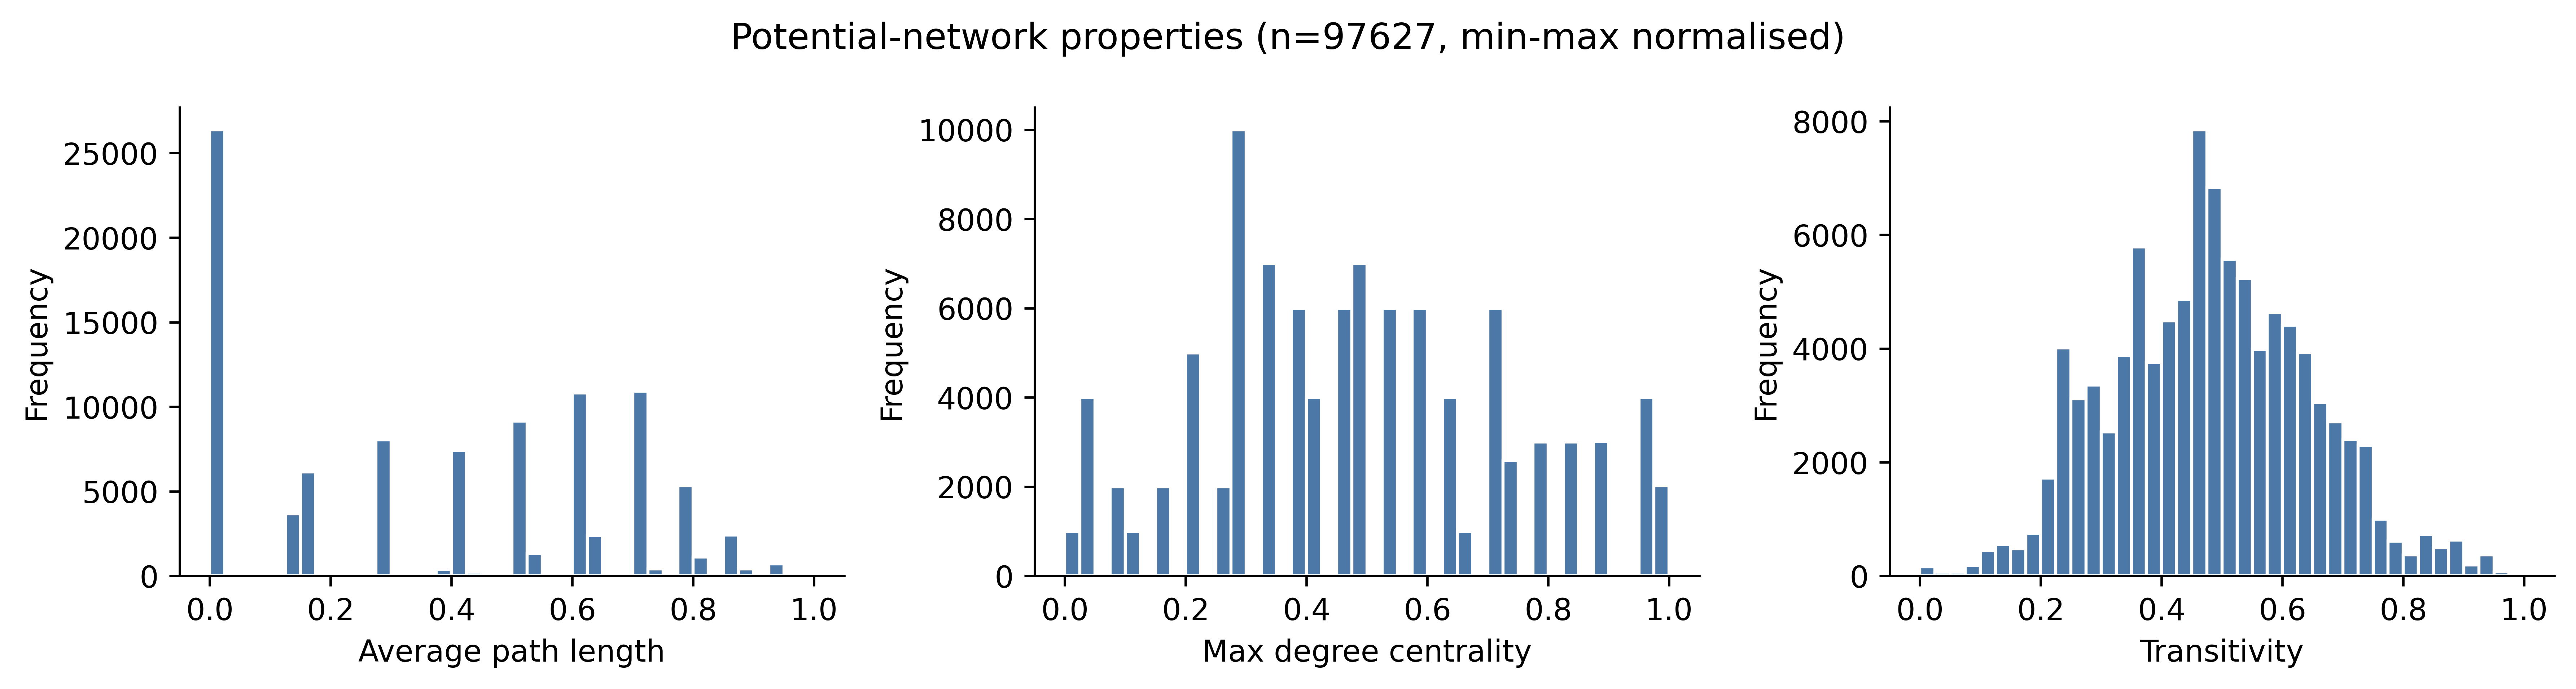

In [7]:
# ---- plot: distributions of the three potential-network properties ----

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), dpi = 600)
for ax, vals, name in zip(axes, [apl, mdc, tr], ['Average path length', 'Max degree centrality', 'Transitivity']):
    ax.hist(vals, bins=40, color='#4C78A8', edgecolor='white')
    ax.set_xlabel(name); ax.set_ylabel('Frequency')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Potential-network properties (n=%d, min-max normalised)' % len(potential_net))
fig.tight_layout(); plt.savefig('breast_potential_properties.png', dpi=150, bbox_inches='tight'); plt.show()

In [8]:
# ---- STEP 3: breast data -> |partial correlation| confidence matrix ----

JAKSTATdata = pd.read_csv(os.path.join(BASE, 'JAKSTATdata.csv'), index_col='GeneID')
JAKSTAT = JAKSTATdata.T[12:37].astype(float)               # 25 samples x 32 genes
JAKSTAT.index = list(range(0, 25))
pcor = JAKSTAT.pcorr().values
genes_all = np.array(JAKSTAT.corr().index)
order = np.argsort(np.sum(np.abs(pcor), axis=0))[::-1]      # sort genes by descending |pcor| sum
C = np.abs(pcor[np.ix_(order, order)])
genes = genes_all[order]
print('confidence matrix C:', C.shape, '| first genes:', list(genes[:3]))

confidence matrix C: (32, 32) | first genes: ['IL22RA2', 'PIK3CA', 'EGF']


In [9]:
# ---- STEP 4: select the top 1% structures (non-isomorphic, smallest Deviation) ----
top_n = int(len(potential_net) * TOP_PERCENT)
selected, graphs = [], []
for idx in np.argsort(deviation):
    if len(selected) >= top_n: break
    g = nx.from_numpy_array(np.array(potential_net[idx]))
    if any(nx.is_isomorphic(gp, g) for gp in reversed(graphs)): continue
    graphs.append(g); selected.append(np.array(potential_net[idx]))
print('selected (top %.0f%%, non-isomorphic):' % (TOP_PERCENT * 100), len(selected), 'structures')


selected (top 1%, non-isomorphic): 976 structures


In [10]:
# ---- STEP 5: labelling function (ACCELERATED: same double-loop score + C' convergence stop) ----

def label_accelerated(current_net, C, genes, seed, Permute_times=PERMUTE_TIMES, Permute_size=PERMUTE_SIZE, Update_count=UPDATE_COUNT, patience=PATIENCE_T):
    random.seed(seed); cn = np.array(current_net); P = len(genes)
    mdn = int(np.where(cn.sum(0) == cn.sum(0).max())[0][0])
    cs = C.sum(0); mcg = genes[int(np.where(cs == cs.max())[0][0])]
    gl = np.array(list(genes)); pc = np.array([int(np.where(gl == mcg)[0][0]), mdn]); gl[pc] = gl[pc[::-1]]
    gc = np.copy(C); gc[:, pc] = gc[:, pc[::-1]]; gc[pc, :] = gc[pc[::-1], :]
    net_score = 0.0
    for jj in range(P): net_score += np.sum(gc[jj] * cn[jj])            # same double loop as original
    nou = tot = 0; ps = Permute_size; stale = 0
    while tot < Permute_times and ps < P:
        cand = random.sample(range(P), ps); aft = cand.copy()
        while aft == cand: aft = random.sample(cand, ps)
        tl = np.copy(gl); tl[cand] = tl[aft]; tc = np.copy(gc); tc[:, cand] = tc[:, aft]; tc[cand, :] = tc[aft, :]
        ts = 0.0
        for jj in range(P): ts += np.sum(tc[jj] * cn[jj])              # same double loop as original
        if ts > net_score: gl = tl; gc = tc; net_score = ts; nou = 0; stale = 0
        else: nou += 1; stale += 1
        tot += 1
        if nou >= Update_count: ps += 1; nou = 0                        # escalate swap size
        if stale >= patience: break                                    # C' convergence stop
    return gl

def label_accelerated_trace(current_net, C, genes, seed, Permute_times=PERMUTE_TIMES, Permute_size=PERMUTE_SIZE, Update_count=UPDATE_COUNT, patience=PATIENCE_T):
    # same search as label_accelerated, but records (best score, swap size) at every iteration for the convergence plot
    random.seed(seed); cn = np.array(current_net); P = len(genes)
    mdn = int(np.where(cn.sum(0) == cn.sum(0).max())[0][0])
    cs = C.sum(0); mcg = genes[int(np.where(cs == cs.max())[0][0])]
    gl = np.array(list(genes)); pc = np.array([int(np.where(gl == mcg)[0][0]), mdn]); gl[pc] = gl[pc[::-1]]
    gc = np.copy(C); gc[:, pc] = gc[:, pc[::-1]]; gc[pc, :] = gc[pc[::-1], :]
    net_score = 0.0
    for jj in range(P): net_score += np.sum(gc[jj] * cn[jj])
    nou = tot = 0; ps = Permute_size; stale = 0; best, swaps = [], []
    while tot < Permute_times and ps < P:
        cand = random.sample(range(P), ps); aft = cand.copy()
        while aft == cand: aft = random.sample(cand, ps)
        tl = np.copy(gl); tl[cand] = tl[aft]; tc = np.copy(gc); tc[:, cand] = tc[:, aft]; tc[cand, :] = tc[aft, :]
        ts = 0.0
        for jj in range(P): ts += np.sum(tc[jj] * cn[jj])
        if ts > net_score: gl = tl; gc = tc; net_score = ts; nou = 0; stale = 0
        else: nou += 1; stale += 1
        best.append(net_score); swaps.append(ps); tot += 1
        if nou >= Update_count: ps += 1; nou = 0
        if stale >= patience: break
    return np.array(best), np.array(swaps)

In [11]:
# ---- STEP 6: label every selected structure (PARALLEL) ----

t0 = time.time()
labels = Parallel(n_jobs=N_JOBS)(delayed(label_accelerated)(selected[k], C, genes, SEED + k) for k in range(len(selected)))
print('labelling: %.1f s' % (time.time() - t0))

labelling: 245.7 s


In [12]:
# ---- STEP 7: ensemble network (edge proportion -> sparsity-matched threshold) ----

P = POTENTIAL_NET_SIZE; Ssum = np.zeros((P, P))
for st, lab in zip(selected, labels):
    match = [int(np.where(lab == genes[j])[0][0]) for j in range(P)]
    Ssum += st[:, match][match, :]
proportion = Ssum / len(selected)
ths = np.arange(0, 1.05, 0.05)
sp = [np.count_nonzero(proportion > t) / (P * (P - 1)) for t in ths]
t_star = ths[int(np.argmin([abs(x - mean_sparsity) for x in sp]))]
ensemble = (proportion > t_star).astype(int); np.fill_diagonal(ensemble, 0)
deg = ensemble.sum(0)
print('t* = %.2f | edges = %d | hub = %s (degree %d)' % (
    t_star, int(ensemble[np.tril_indices(P, -1)].sum()), genes[int(np.argmax(deg))], int(deg.max())))
pd.DataFrame(ensemble, index=genes, columns=genes).to_csv('Ensemble_network_breast_accelerated.csv')
print('saved Ensemble_network_breast_accelerated.csv')

t* = 0.65 | edges = 21 | hub = IL22RA2 (degree 11)
saved Ensemble_network_breast_accelerated.csv


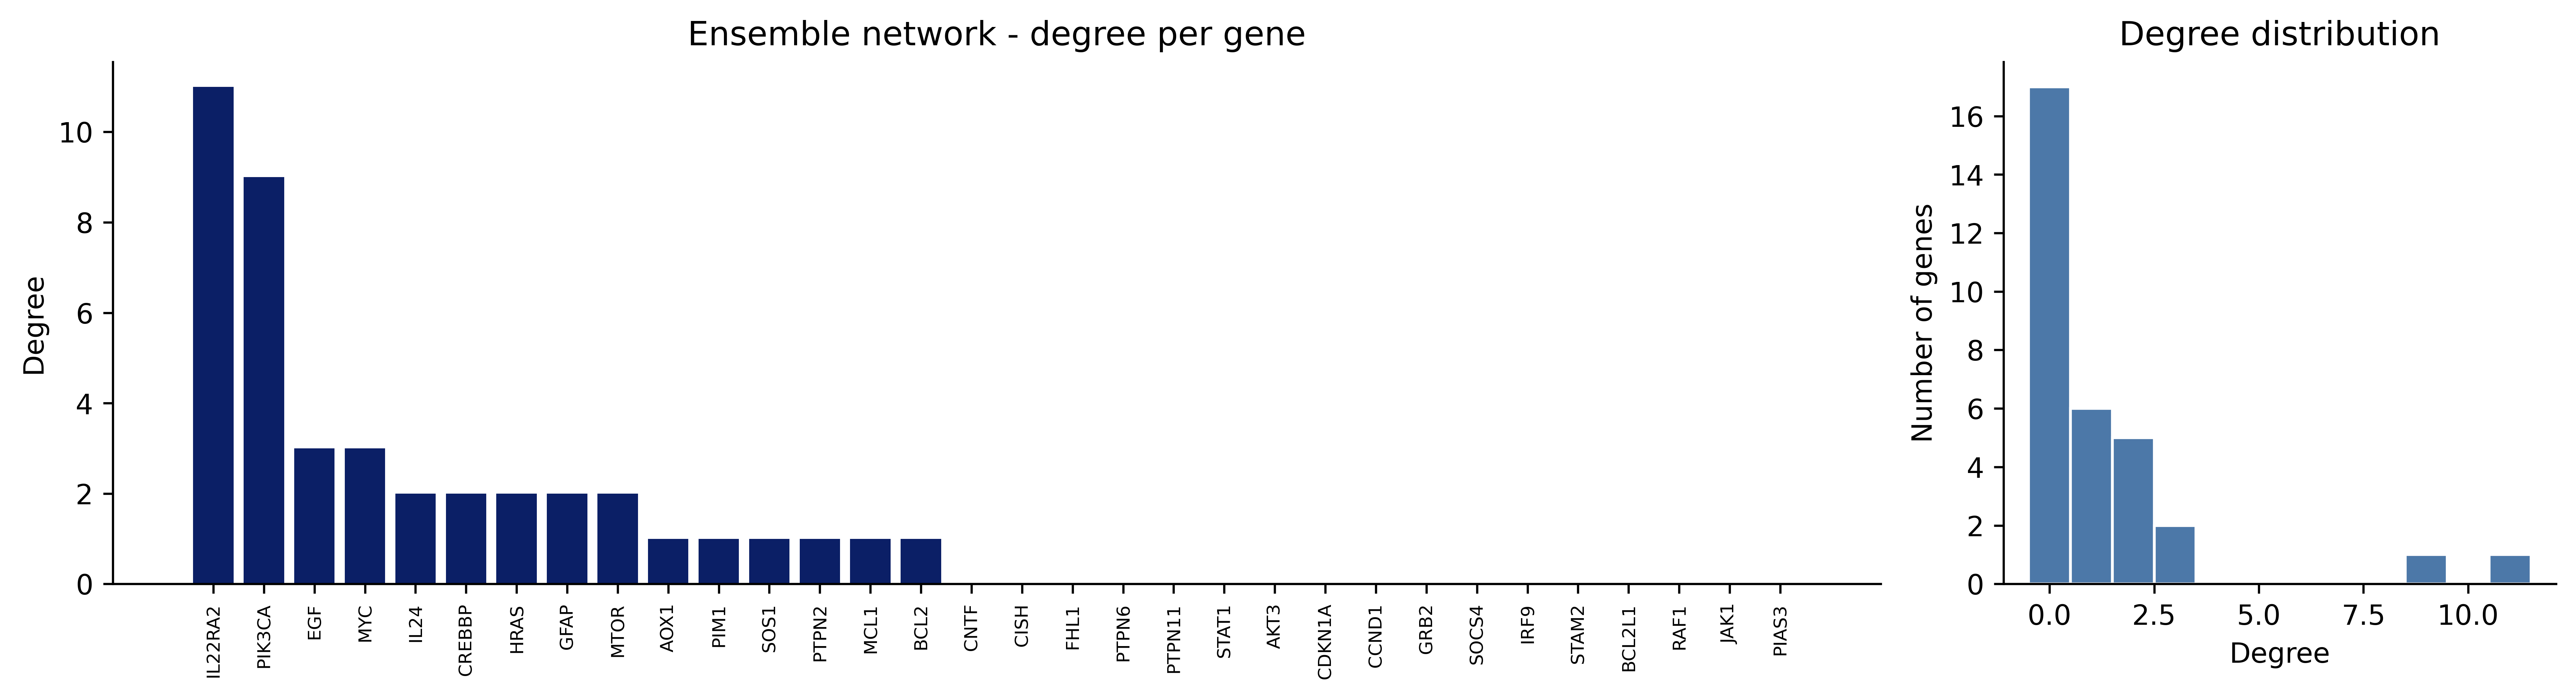

In [13]:
# ---- plot: ensemble degree distribution (per-gene bar + histogram) ----

deg = ensemble.sum(0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={'width_ratios': [3.2, 1]}, dpi=600)
od = np.argsort(-deg)
a1.bar(range(P), deg[od], color='#0B1F66')
a1.set_xticks(range(P)); a1.set_xticklabels([genes[i] for i in od], rotation=90, fontsize=6.5)
a1.set_ylabel('Degree'); a1.set_title('Ensemble network - degree per gene')
a1.spines['top'].set_visible(False); a1.spines['right'].set_visible(False)
a2.hist(deg, bins=range(0, int(deg.max()) + 2), color='#4C78A8', edgecolor='white', align='left')
a2.set_xlabel('Degree'); a2.set_ylabel('Number of genes'); a2.set_title('Degree distribution')
a2.spines['top'].set_visible(False); a2.spines['right'].set_visible(False)
fig.tight_layout(); plt.savefig('breast_ensemble_degree.png', dpi=150, bbox_inches='tight'); plt.show()

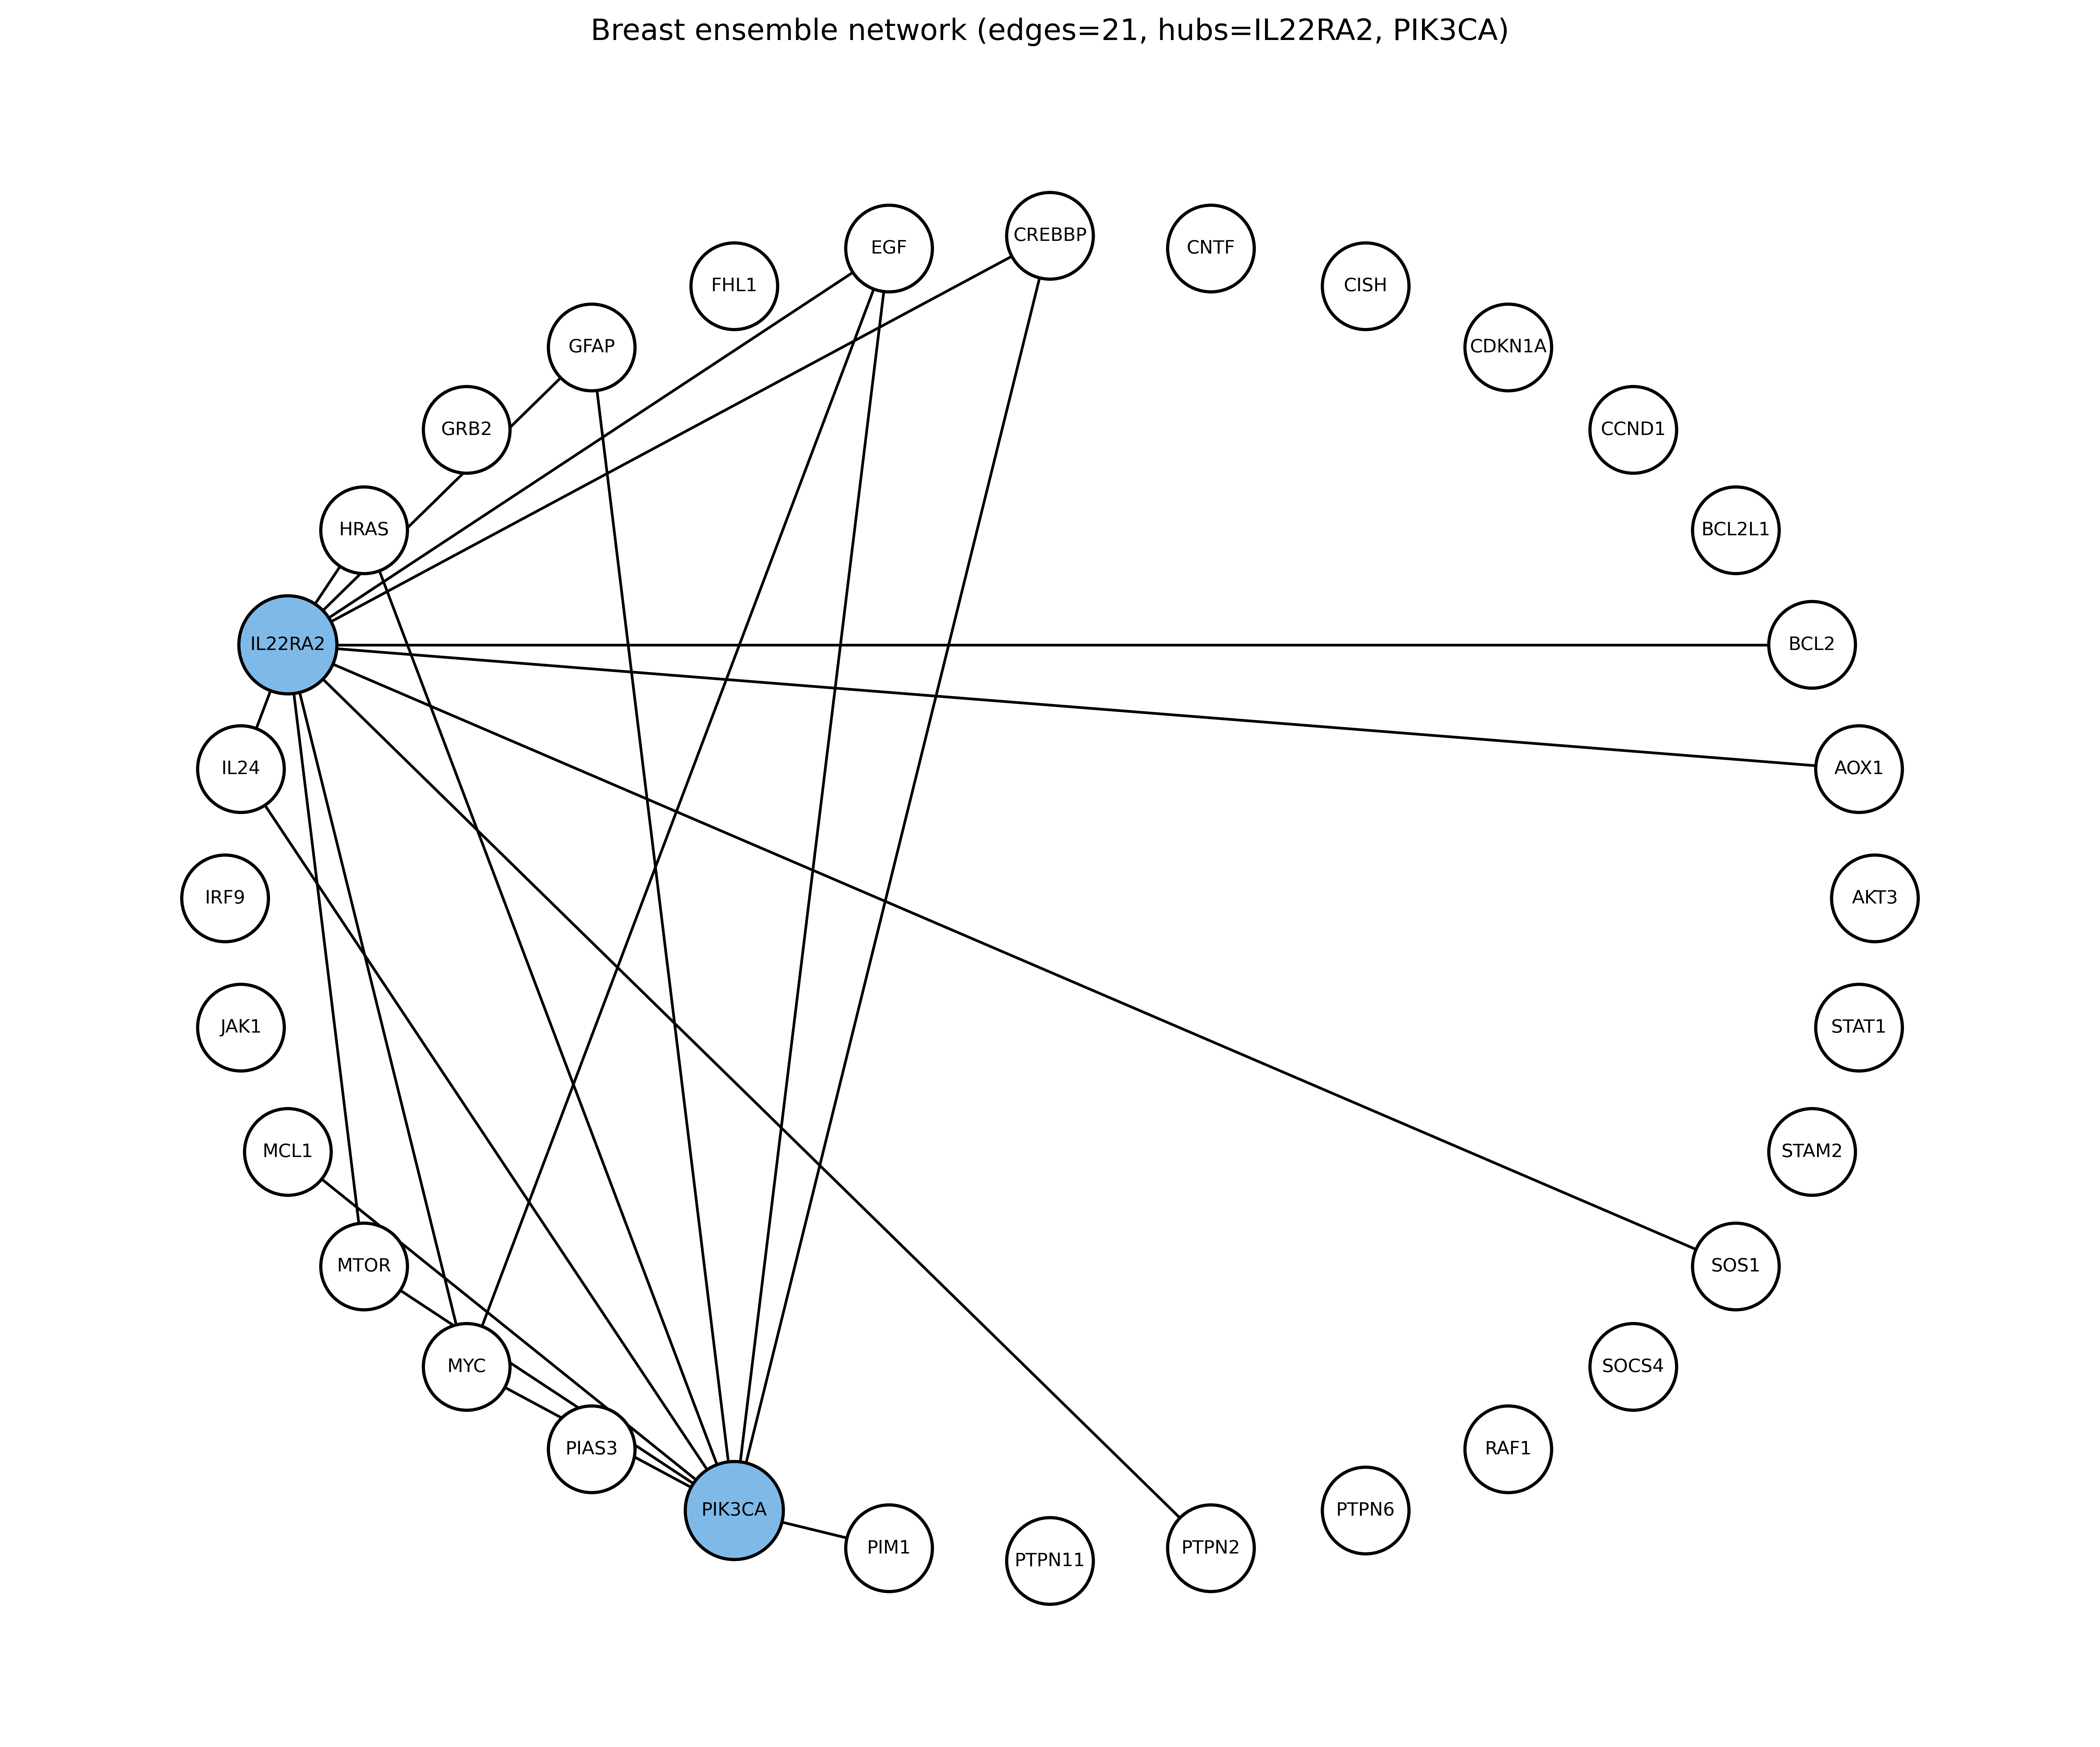

In [14]:
# ---- plot: ensemble network, reference style (circular layout; top-2 hubs light blue) ----

ridx = [list(genes).index(g) for g in genes_all]
Eo = ensemble[np.ix_(ridx, ridx)]; go = [str(g) for g in genes_all]; dego = Eo.sum(0)
hub_idx = list(np.argsort(-dego, kind='stable')[:2])
G = nx.from_numpy_array(Eo); pos = nx.circular_layout(G)
node_colors = ['#7FB9E8' if i in hub_idx else 'white' for i in range(P)]
node_sizes = [1600 if i in hub_idx else 1250 for i in range(P)]
fig, ax = plt.subplots(figsize=(12, 10), dpi=600)
nx.draw_networkx_edges(G, pos, edge_color='black', width=1.1, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='black', linewidths=1.3, ax=ax)
nx.draw_networkx_labels(G, pos, labels={i: go[i] for i in range(P)}, font_size=7.5, ax=ax)
ax.axis('off'); ax.margins(0.08)
ax.set_title('Breast ensemble network (edges=%d, hubs=%s)' % (int(Eo[np.tril_indices(P, -1)].sum()), ', '.join(go[i] for i in hub_idx)))
fig.tight_layout(); plt.savefig('breast_ensemble_network.png', dpi=200, bbox_inches='tight'); plt.show()

## Labelling convergence of the top-ranked structures (C')

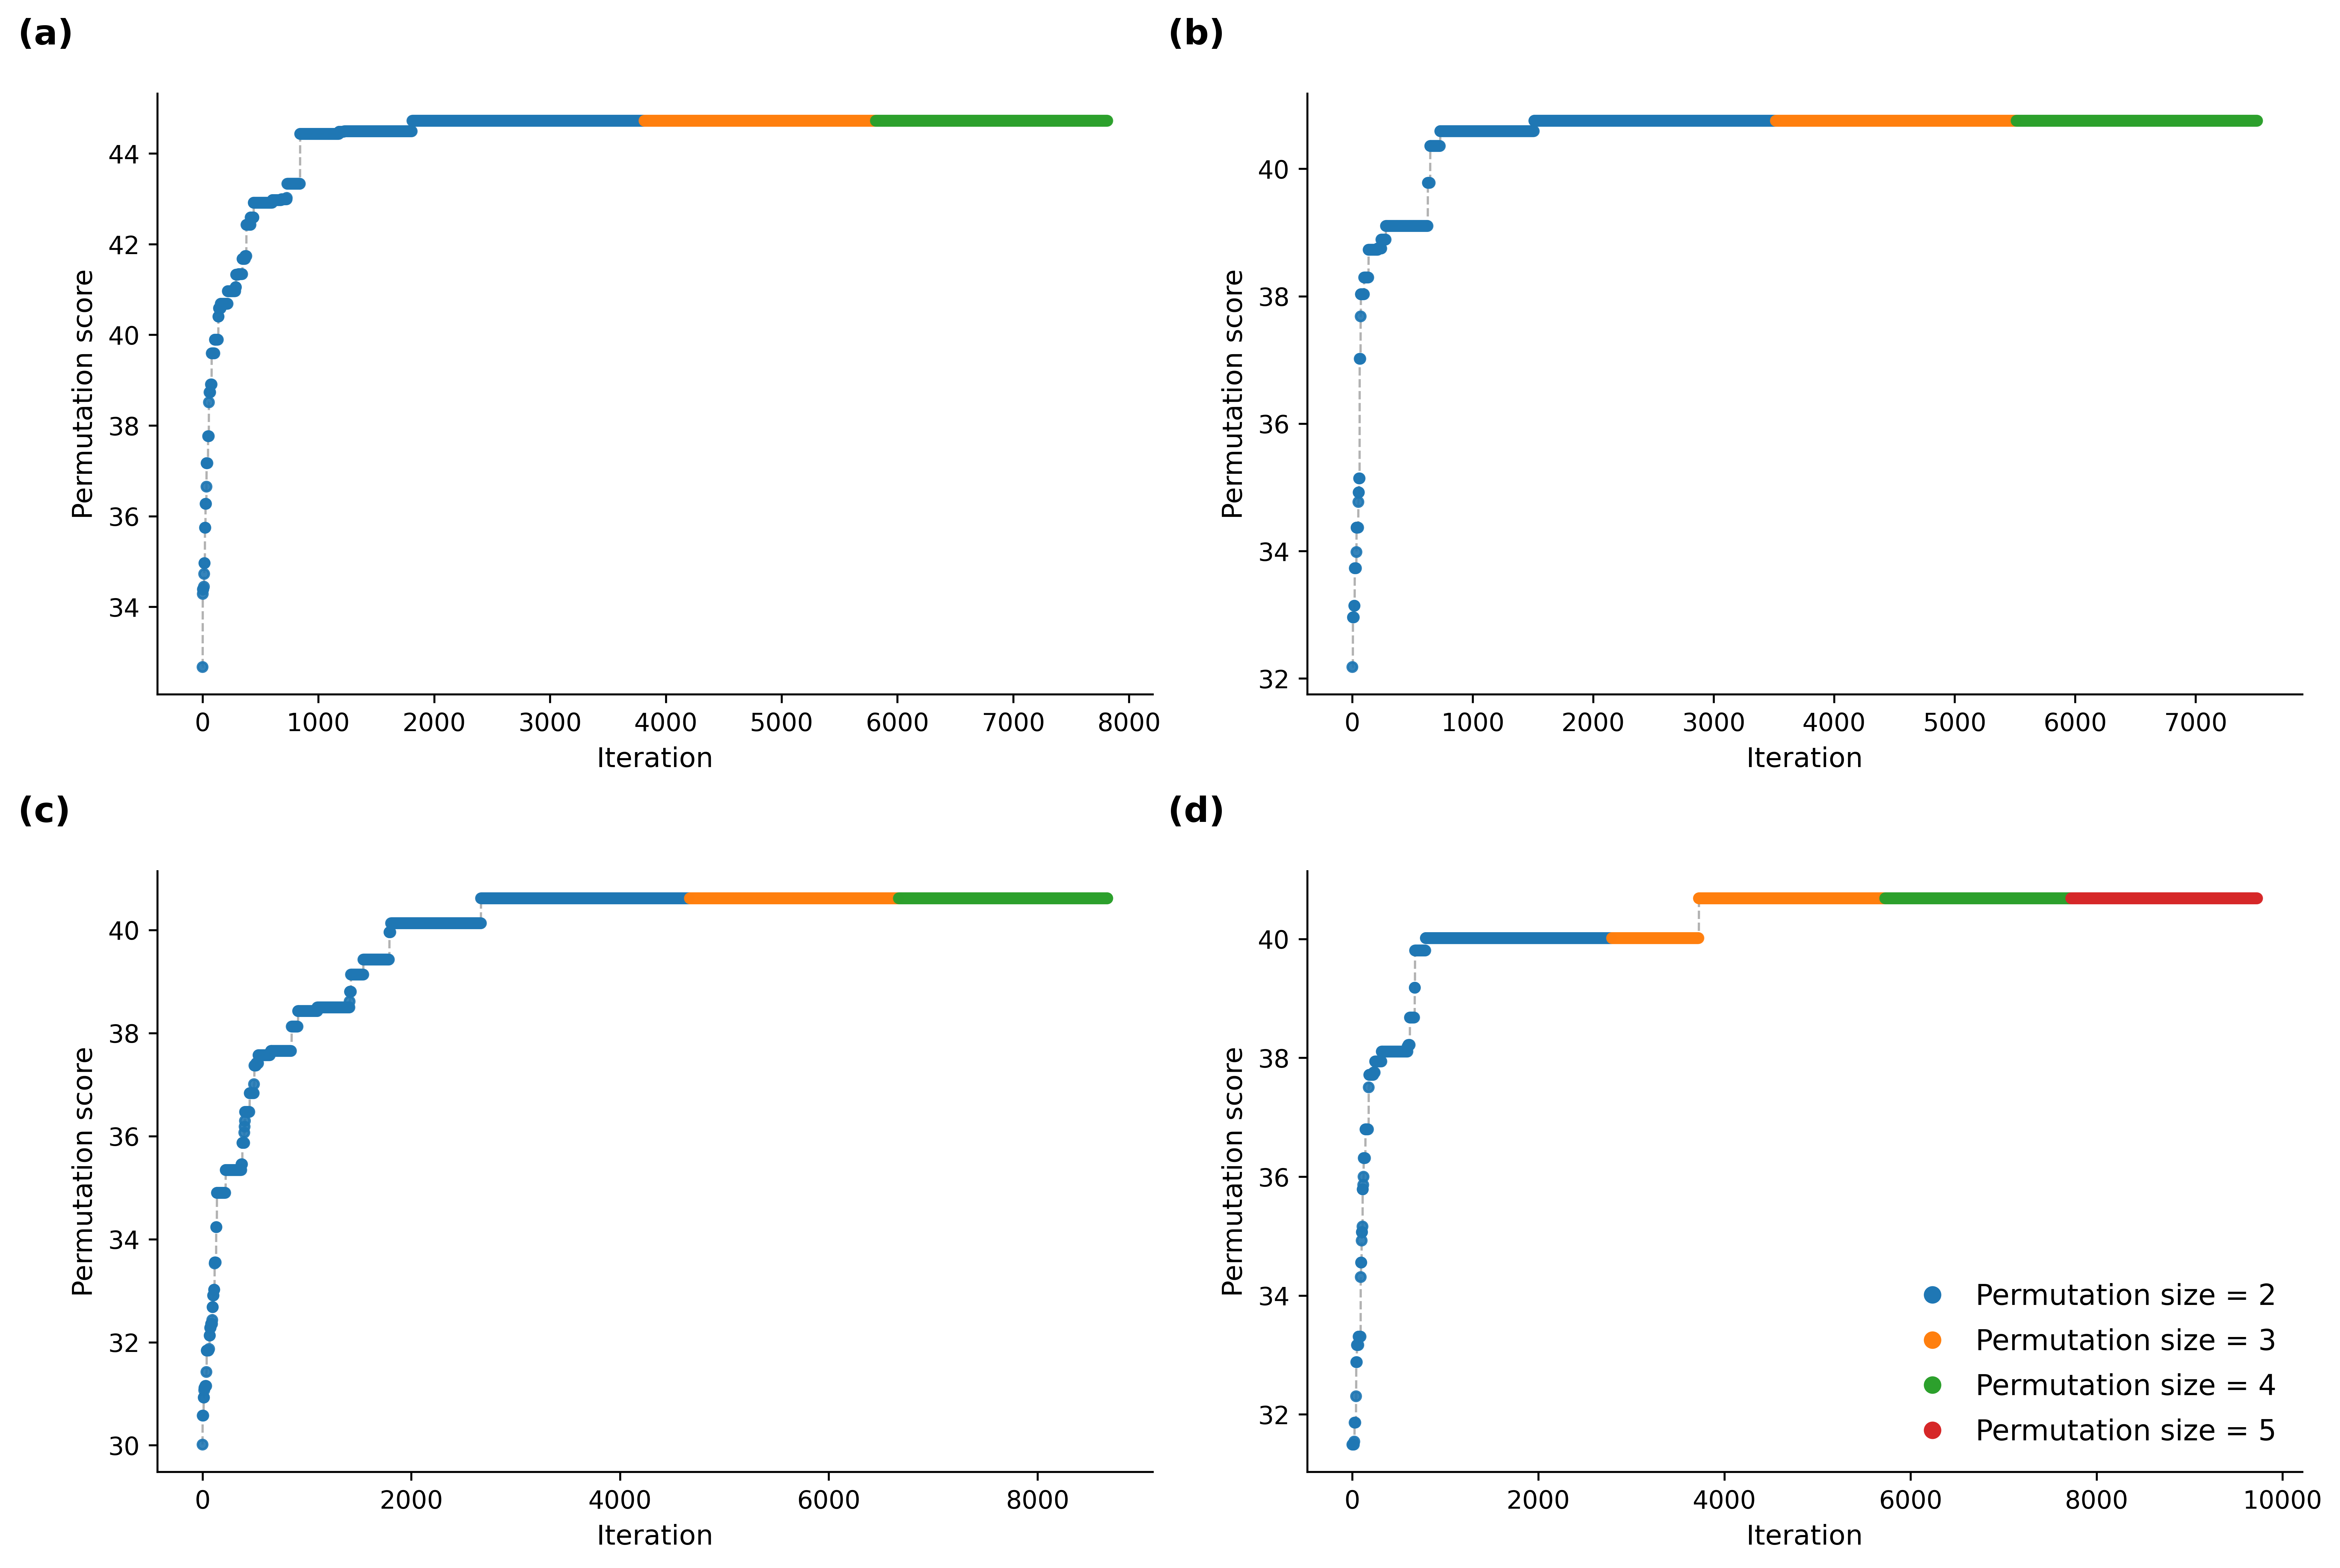

In [15]:
# ---- plot: labelling convergence for the top-4 structures (C' escalation + convergence stop) ----
from matplotlib.lines import Line2D
traces = [label_accelerated_trace(selected[k], C, genes, SEED + k) for k in range(4)]
allsizes = sorted(set(int(s) for b, sw in traces for s in sw))
cmap = plt.cm.tab10; colmap = {s: cmap(i % 10) for i, s in enumerate(allsizes)}
fig, axes = plt.subplots(2, 2, figsize=(13, 8.8), dpi=600)
for i, (b, sw) in enumerate(traces):
    ax = axes[i // 2][i % 2]; x = np.arange(len(b))
    ax.plot(x, b, color='0.5', lw=0.9, ls='--', alpha=0.6, zorder=1)
    keep = np.unique(np.concatenate([[0, len(b) - 1], np.where(np.diff(b) != 0)[0] + 1, np.arange(0, len(b), max(1, len(b) // 1200))]))
    ax.scatter(x[keep], b[keep], c=[colmap[int(s)] for s in sw[keep]], s=14, alpha=0.9, zorder=3)
    ax.set_xlabel('Iteration', fontsize=11); ax.set_ylabel('Permutation score', fontsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.text(-0.14, 1.07, '(%s)' % 'abcd'[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='bottom', ha='left')
handles = [Line2D([0], [0], marker='o', ls='', color=colmap[s], label='Permutation size = %d' % s) for s in allsizes]
axes[1][1].legend(handles=handles, fontsize=11.5, loc='lower right', ncol=1, frameon=False, labelspacing=0.6, handletextpad=0.5)
fig.tight_layout(); plt.savefig('breast_labelling_convergence_top4.png', dpi=150, bbox_inches='tight'); plt.show()
